In [30]:
# 📦 STEP 1: Load Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [31]:
# 📂 STEP 2: Load Data
df = pd.read_csv("Year Order Item Data.csv", parse_dates=['date'])

# Quick glance at data
df.head()

,restaurant_name,invoice_no,date,payment_type,order_type,status,area,virtual_brand_name,brand_grouping,assign_to,customer_phone,customer_name,customer_address,persons,order_cancel_reason,my_amount,total_tax,discount,delivery_charge,container_charge,service_charge,additional_charge,waived_off,round_off,total,item_name,category_name,sap_code,item_price,item_quantity,item_total
0,Makers of Milkshakes - Prozone Mall,1,2024-04-01 11:32:59,Cash,Pick Up,Success,Parcel,NaN,Offline Menu,NaN,8.390407e+09,slma saphir,NaN,NaN,NaN,344.23,30.78,0.0,0,0,0,0,0,-0.01,375,Strawberry Shake (Milkshake),Classic Shakes,NaN,160.64,1,160.64
1,Makers of Milkshakes - Prozone Mall,1,2024-04-01 11:32:59,Cash,Pick Up,Success,Parcel,NaN,Offline Menu,NaN,8.390407e+09,slma saphir,NaN,NaN,NaN,344.23,30.78,0.0,0,0,0,0,0,-0.01,375,Chocolate Shake (Milkshake),Instashakes,NaN,183.59,1,183.59
2,Makers of Milkshakes - Prozone Mall,2,2024-04-01 12:05:34,Cash,Pick Up,Success,Parcel,NaN,Offline Menu,NaN,9.373995e+09,rahat khan,NaN,NaN,NaN,137.69,12.30,0.0,0,0,0,0,0,0.01,150,Classic Lemonade,Coolers,NaN,137.69,1,137.69
3,Makers of Milkshakes - Prozone Mall,3,2024-04-01 12:12:00,Cash,Pick Up,Success,Parcel,NaN,Offline Menu,NaN,8.149381e+09,sania khan,NaN,NaN,NaN,367.18,32.82,0.0,0,0,0,0,0,0.00,400,Waffles,Waffles,NaN,183.59,2,367.18
4,Makers of Milkshakes - Prozone Mall,4,2024-04-01 12:13:51,Other [UPI],Pick Up,Success,Parcel,NaN,Offline Menu,NaN,9.156525e+09,pawna mothkuwan,NaN,NaN,NaN,367.18,32.82,0.0,0,0,0,0,0,0.00,400,Banana Shake (Milkshake),Fruit Walker,NaN,183.59,1,183.59


In [32]:
# 🧹 STEP 3: Clean Data Types & Handle Missing
numeric_cols = [
    'my_amount', 'total_tax', 'discount', 'delivery_charge',
    'container_charge', 'service_charge', 'additional_charge',
    'waived_off', 'round_off', 'total', 'item_price', 'item_quantity', 'item_total'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill common missing numeric fields with 0
df[['discount', 'waived_off']] = df[['discount', 'waived_off']].fillna(0)

# Drop records missing critical order-level info
df.dropna(subset=['invoice_no', 'item_name', 'item_quantity', 'item_total'], inplace=True)

# Recompute net sales at line level
df['net_sales'] = df['item_total'] - df[['discount', 'waived_off']].sum(axis=1)

# Time-based features
df['YearMonth'] = df['date'].dt.to_period('M')
df['DateOnly'] = df['date'].dt.date
df['Weekday'] = df['date'].dt.day_name()
df['Hour'] = df['date'].dt.hour

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15712 entries, 0 to 15711
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   restaurant_name      15712 non-null  object        
 1   invoice_no           15712 non-null  int64         
 2   date                 15712 non-null  datetime64[ns]
 3   payment_type         15712 non-null  object        
 4   order_type           15712 non-null  object        
 5   status               15712 non-null  object        
 6   area                 15697 non-null  object        
 7   virtual_brand_name   0 non-null      float64       
 8   brand_grouping       15227 non-null  object        
 9   assign_to            0 non-null      float64       
 10  customer_phone       8378 non-null   float64       
 11  customer_name        8562 non-null   object        
 12  customer_address     152 non-null    object        
 13  persons              0 non-null

In [33]:
# 🧮 STEP 4: Invoice-Level KPI Aggregation

invoice_kpis = (
    df.groupby('invoice_no').agg(
        order_date=('date', 'min'),
        customer_phone=('customer_phone', 'first'),
        customer_name=('customer_name', 'first'),
        total_items=('item_name', 'nunique'),
        total_quantity=('item_quantity', 'sum'),
        total_discount=('discount', 'sum'),
        total_waived_off=('waived_off', 'sum'),
        net_invoice_value=('net_sales', 'sum')
    ).reset_index()
)

# Add easy date breakdowns
invoice_kpis['order_day'] = invoice_kpis['order_date'].dt.day_name()
invoice_kpis['order_date_only'] = invoice_kpis['order_date'].dt.date

invoice_kpis.head()

,invoice_no,order_date,customer_phone,customer_name,total_items,total_quantity,total_discount,total_waived_off,net_invoice_value,order_day,order_date_only
0,1,2024-04-01 11:32:59,8.390407e+09,slma saphir,2,2,0.0,0,344.23,Monday,2024-04-01
1,2,2024-04-01 12:05:34,9.373995e+09,rahat khan,1,1,0.0,0,137.69,Monday,2024-04-01
2,3,2024-04-01 12:12:00,8.149381e+09,sania khan,1,2,0.0,0,367.18,Monday,2024-04-01
3,4,2024-04-01 12:13:51,9.156525e+09,pawna mothkuwan,2,2,0.0,0,367.18,Monday,2024-04-01
4,5,2024-04-01 14:32:03,9.405067e+09,ghule patil,2,3,0.0,0,504.87,Monday,2024-04-01


In [34]:
# 💾 Save for future use
invoice_kpis.to_csv("../results/order_analysis/Invoice_Aggregation.csv", index=False)

In [35]:
# 🤝 STEP 5: Build Product Co-Occurrence
# Group items by invoice
invoice_items = df.groupby('invoice_no')['item_name'].apply(list).reset_index()

# Check basic basket stats
invoice_items['basket_size'] = invoice_items['item_name'].apply(lambda x: len(set(x)))
invoice_items['basket_size'].describe()

count    11367.000000
mean         1.368699
std          0.667077
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: basket_size, dtype: float64

In [36]:
# Function to build pair counts
def build_pair_counter(item_lists):
    pair_counter = Counter()
    for items in item_lists:
        unique_items = list(set(items))
        if len(unique_items) > 1:
            pairs = combinations(sorted(unique_items), 2)
            pair_counter.update(pairs)
    return pair_counter

# Build pair counts
pair_counter = build_pair_counter(invoice_items['item_name'])
pair_counter.most_common(10)

[(('Cold Coffee', 'Waffles'), 95),
 (('Cold Coffee', 'Strawberry Shake (Milkshake)'), 69),
 (('Blackcurrant Shake (Milkshake)', 'Strawberry Shake (Milkshake)'), 64),
 (('Blue Curacao', 'Classic Lemonade'), 58),
 (('Blue Curacao', 'Cold Coffee'), 55),
 (('Chocolate Shake (Milkshake)', 'Strawberry Shake (Milkshake)'), 52),
 (('Strawberry Shake (Milkshake)', 'Waffles'), 50),
 (('Classic Lemonade', 'Cold Coffee'), 45),
 (('Cad-b', 'Cold Coffee'), 45),
 (('Chocolate Shake (Milkshake)', 'Waffles'), 38)]

In [37]:
# Convert to dataframe for analysis
co_occurrence_df = pd.DataFrame(pair_counter.items(), columns=['item_pair', 'count'])
co_occurrence_df[['item_1', 'item_2']] = pd.DataFrame(co_occurrence_df['item_pair'].tolist(), index=co_occurrence_df.index)
co_occurrence_df.drop(columns='item_pair', inplace=True)
co_occurrence_df.sort_values(by='count', ascending=False, inplace=True)

co_occurrence_df.head()

,count,item_1,item_2
578,95,Cold Coffee,Waffles
8,69,Cold Coffee,Strawberry Shake (Milkshake)
96,64,Blackcurrant Shake (Milkshake),Strawberry Shake (Milkshake)
16,58,Blue Curacao,Classic Lemonade
807,55,Blue Curacao,Cold Coffee


In [38]:
# 🔥 STEP 6: Symmetric Co-Occurrence Matrix

matrix_df = pd.pivot_table(
    co_occurrence_df,
    values='count',
    index='item_1',
    columns='item_2',
    fill_value=0
)

# Make it symmetric
full_matrix = matrix_df + matrix_df.T.fillna(0)

full_matrix.head()

,5 Star Shake (Milkshake),5 Star Shake (Thickshake),Anjir,Banana Crunch (Thickshake),Banana Crunch Shake (Milkshake),Banana Crunch Shake (Thickshake),Banana Fruit Walker (Milkshake),Banana Shake (Milkshake),Banana Shake (Thickshake),Belgium Dark Chocolate Brownie Shake (Milkshake),Belgium Dark Chocolate Brownie Shake (Thickshake),Belgium Dark Chocolate Shake (Milkshake),Belgium Dark Chocolate Shake (Thickshake),Berryblast,Biscoff,Blackcurrant Crunch Shake (Milkshake),Blackcurrant Crunch Shake (Thickshake),Blackcurrant Shake (Milkshake),Blackcurrant Shake (Thickshake),Blackcurrent Crunch (Milkshake),Blackcurrent Shake (Milkshake),Blackcurrent Shake (Thickshake),Blue Curacao,Blue Curacao Cooler,Blueberry,Brownie Nuts (Thickshake),Brownie Nuts Shake (Milkshake),Brownie Nuts Shake (Thickshake),Bubblegum,Cad-b,Caramel Shake (Milkshake),Caramel Shake (Thickshake),Chilli Guava,Chilli Guava Cooler,Chilli Pineapple,Chilli Pineapple Cooler,Choco Chip Brownie (Milkshake),Choco Chip Brownie (Thickshake),Choco Dip Cookies Shake (Milkshake),Choco Oreo Shake (Milkshake),Choco Oreo Shake (Thickshake),Choco-A-List Shake (Milkshake),Choco-A-List Shake (Thickshake),Choco-Chip,Choco-Chip Banana (Milkshake),Choco-Chip Banana (Thickshake),Choco-Chip Banana Shake (Milkshake),Choco-Chip Banana Shake (Thickshake),Choco-Chip Brownie Shake (Milkshake),Choco-Chip Brownie Shake (Thickshake),Choco-Dip Cookies Shake (Milkshake),Choco-Dip Cookies Shake (Thickshake),Choco-chip Banana (Thickshake),Chocolate Brownie (Milkshake),Chocolate Brownie (Thickshake),Chocolate Brownie Shake (Milkshake),Chocolate Brownie Shake (Thickshake),Chocolate Shake (Milkshake),Chocolate Shake (Thickshake),Chocolate Strawberry Shake (Milkshake),Chocolate Strawberry Shake (Thickshake),Chocolate Waffle,Classic Lemonade,Classic Lemonade Cooler,Classic Waffles,Coffee Brownie (Milkshake),Coffee Brownie (Thickshake),Coffee Brownie Shake (Milkshake),Coffee Brownie Shake (Thickshake),Coffee Shake (Milkshake),Coffee Shake (Thickshake),Cold Coffee,Cold Coffee Cooler,Cookest N Cream Shake (Milkshake),Cookest N Cream Shake (Thickshake),Cookie N Cream Shake (Milkshake),Custard Apple (sitaphal),Dates Shake (Milkshake),Dates Shake (Thickshake),Day-night Waffles,Dry Fruit Shake (Milkshake),Dry Fruit Shake (Thickshake),Dry Fruit Waffles,Fruit A List Shake (Milkshake),Fruit A List Shake (Thickshake),Fruit-A-List Shake (Milkshake),Fruit-A-List Shake (Thickshake),Green Apple,Hazelnut Coffee,Hazelnut Shake (Milkshake),Hazelnut Shake (Thickshake),Ice Cream,Ice Crush Coffee,Kitkat,Kitkat Shake,Kitkat Shake (Milkshake),Kitkat Shake (Thickshake),Kulfi Nuts Shake (Milkshake),Kulfi Nuts Shake (Thickshake),Kulfi Shake (Milkshake),Kulfi Shake (Thickshake),Lemonade,Lichi,Mango (Milkshake),Mango (Thickshake),Mango Shake (Milkshake),Mango Shake (Thickshake),Mocha Coffee,Munch Shake (Milkshake),Munch Shake (Thickshake),Nutella Brownie Shake (Milkshake),Nutella Brownie Shake (Thickshake),Nutella Waffles,Oreo,Oreo 'Go' Nuts Shake (Milkshake),Oreo 'Go' Nuts Shake (Thickshake),Oreo Banana (Milkshake),Oreo Banana (Thickshake),Oreo Banana Shake (Milkshake),Oreo Banana Shake (Thickshake),Oreo Brownie (Milkshake),Oreo Brownie (Thickshake),Oreo Brownie Shake (Milkshake),Oreo Brownie Shake (Thickshake),Oreo Go Nuts Shake (Milkshake),Oreo Shake (Milkshake),Oreo Shake (Thickshake),Pan Shake (Milkshake),Pan Shake (Thickshake),Peanut Butter Banana (Milkshake),Peanut Butter Banana (Thickshake),Peanut Butter Banana Shake (Milkshake),Peanut Butter Banana Shake (Thickshake),Peanut Butter Brownie Shake (Milkshake),Peanut Butter Brownie Shake (Thickshake),Peanut Butter Masala (Milkshake),Peanut Butter Shake (Milkshake),Peanut Butter Shake (Thickshake),Pineapple,Pineapple Mojito,Red Velvet,Red Velvet Shake,Rose,Rose Lemonade,Snickers Shake (Milkshake),Snickers Shake (Thickshake),Strawberry Banana (Milkshake),Strawberry Banana (Thickshake),Strawberry Banana Shake (Milkshake),Strawberry Banana Shake (Thickshake),Strawberry Cooler,Strawb

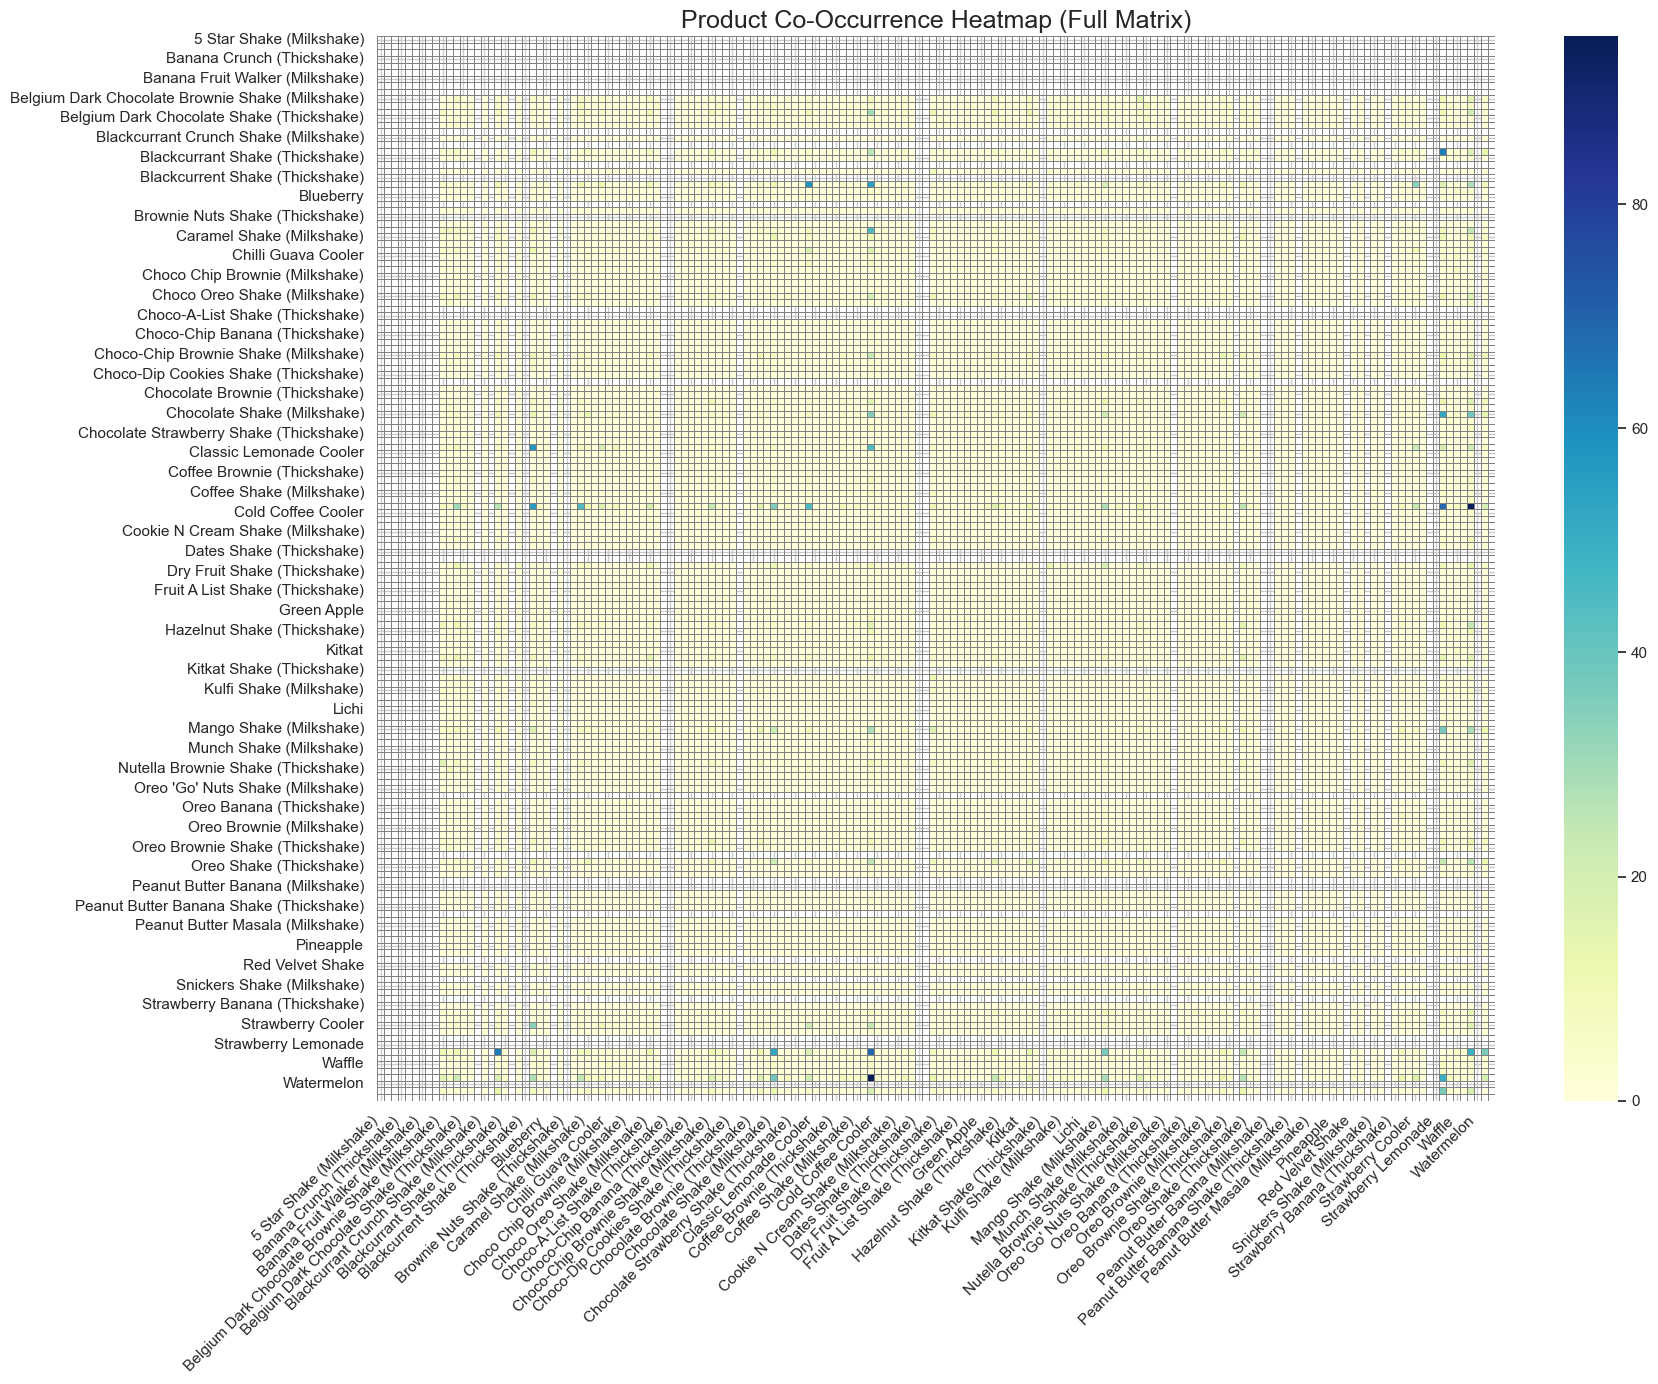

In [39]:
# 🌡️ STEP 7: Heatmap for ALL Co-Occurrences

plt.figure(figsize=(18, 14))
sns.heatmap(full_matrix, cmap='YlGnBu', linewidths=0.5, linecolor='gray')

plt.title("Product Co-Occurrence Heatmap (Full Matrix)", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

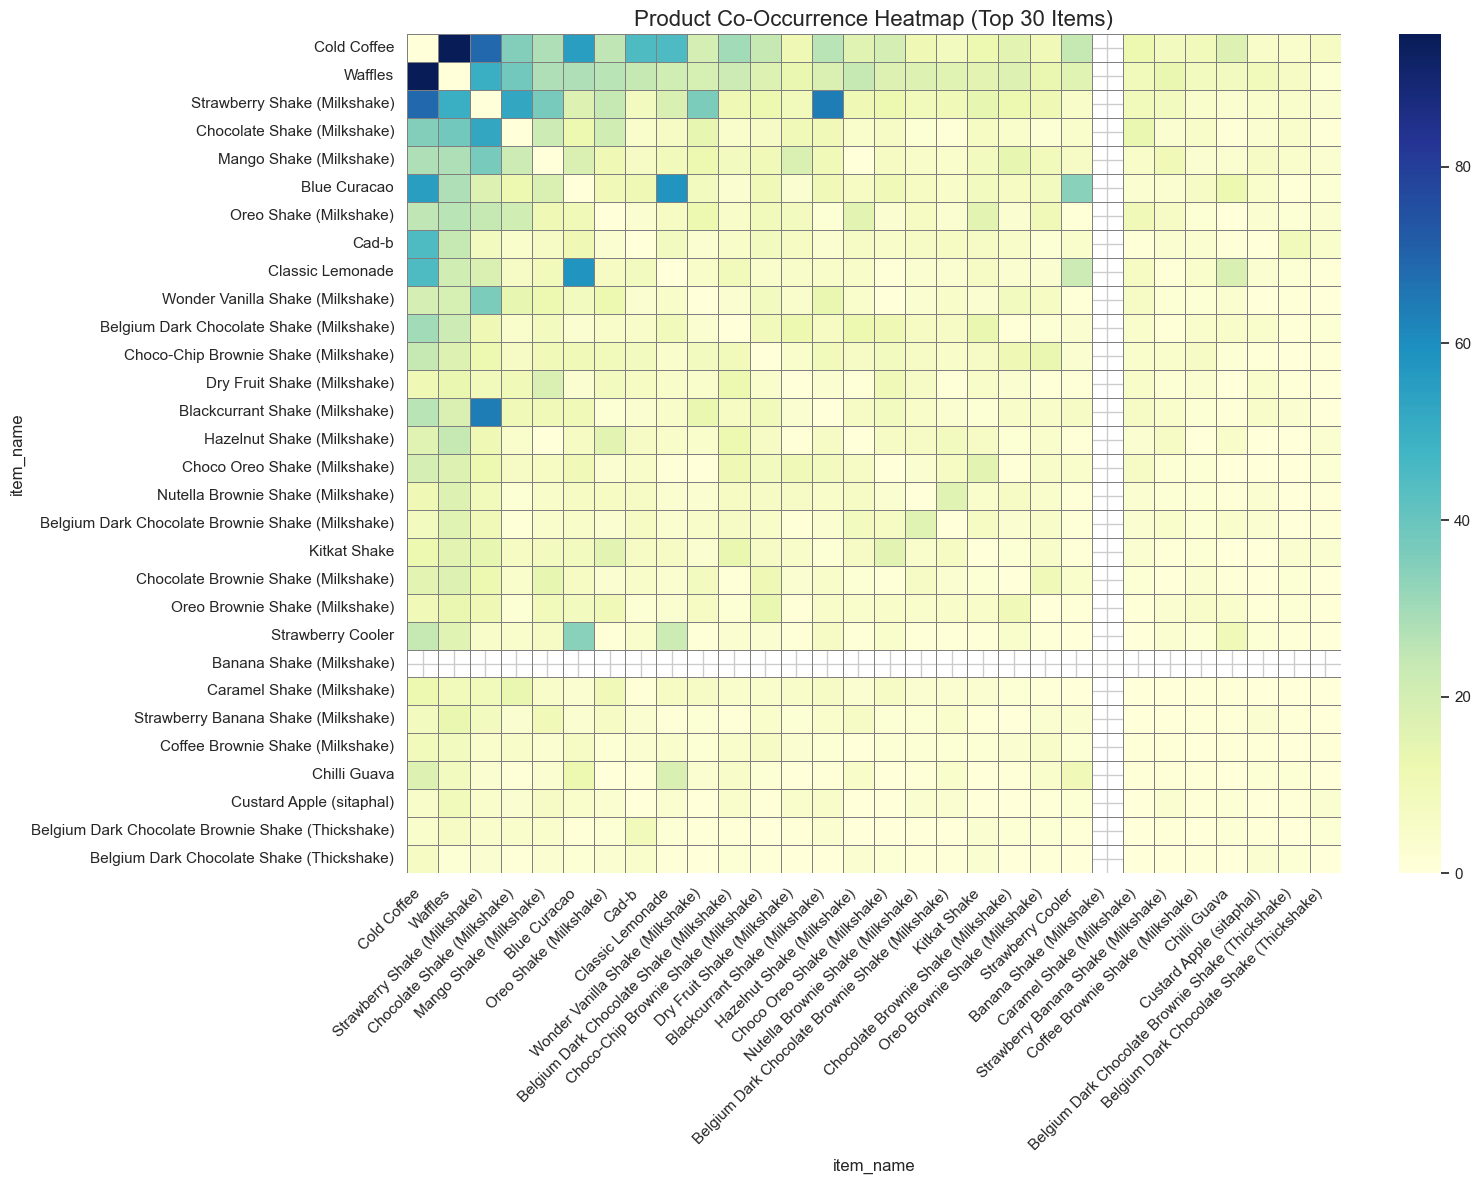

In [40]:
# 🎯 STEP 8: Filtered Heatmap for Top-N frequent items
top_items = df['item_name'].value_counts().head(30).index
filtered_matrix = full_matrix.loc[top_items, top_items]

plt.figure(figsize=(16, 12))
sns.heatmap(filtered_matrix, cmap='YlGnBu', linewidths=0.5, linecolor='gray')

plt.title("Product Co-Occurrence Heatmap (Top 30 Items)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# 💾 Save matrices
# full_matrix.to_csv("../results/order_analysis/Product_Co_occurrence_Full.csv")
filtered_matrix.to_csv("../results/order_analysis/Product_Co_occurrence_Top30.csv")

In [42]:
# 🏋️ STEP 9: Compute Lift Metrics (with support filtering)

min_item_support = 20  # each item must appear in at least 20 invoices
min_pair_support = 5   # each pair must co-occur in at least 5 invoices

# Number of unique invoices
total_invoices = df['invoice_no'].nunique()

# Frequency (support) of each individual item
item_invoice_counts = df.groupby('item_name')['invoice_no'].nunique()
item_invoice_support = item_invoice_counts / total_invoices

# Filter items by minimum support
frequent_items = item_invoice_counts[item_invoice_counts >= min_item_support].index.tolist()

print(f"Found {len(frequent_items)} items with at least {min_item_support} invoices.")

filtered_pairs_df = co_occurrence_df[
    co_occurrence_df['item_1'].isin(frequent_items) &
    co_occurrence_df['item_2'].isin(frequent_items) &
    (co_occurrence_df['count'] >= min_pair_support)
].copy()

print(f"Reduced to {filtered_pairs_df.shape[0]} item pairs after filtering.")

filtered_pairs_df.head()


Found 80 items with at least 20 invoices.
Reduced to 251 item pairs after filtering.


,count,item_1,item_2
578,95,Cold Coffee,Waffles
8,69,Cold Coffee,Strawberry Shake (Milkshake)
96,64,Blackcurrant Shake (Milkshake),Strawberry Shake (Milkshake)
16,58,Blue Curacao,Classic Lemonade
807,55,Blue Curacao,Cold Coffee


In [52]:
def compute_lift(row):
    A, B = row['item_1'], row['item_2']
    pair_support = row['count'] / total_invoices
    expected_support = item_invoice_support[A] * item_invoice_support[B]
    if expected_support > 0:
        return pair_support / expected_support
    else:
        return np.nan

filtered_pairs_df['lift'] = filtered_pairs_df.apply(compute_lift, axis=1)

# Sort by lift descending
filtered_pairs_df.sort_values(by='lift', ascending=True, inplace=True)
filtered_pairs_df['item_1_count'] = filtered_pairs_df['item_1'].map(item_invoice_counts)
filtered_pairs_df['item_2_count'] = filtered_pairs_df['item_2'].map(item_invoice_counts)
filtered_pairs_df.head(15)


,count,item_1,item_2,lift,item_1_count,item_2_count
574,8,Belgium Dark Chocolate Brownie Shake (Milkshake),Cold Coffee,0.149124,249,2449
853,11,Cold Coffee,Dry Fruit Shake (Milkshake),0.151503,2449,337
575,6,Banana Shake (Milkshake),Cold Coffee,0.171907,162,2449
850,5,Cold Coffee,Custard Apple (sitaphal),0.181308,2449,128
690,11,Cold Coffee,Nutella Brownie Shake (Milkshake),0.202605,2449,252
739,28,Cold Coffee,Mango Shake (Milkshake),0.221400,2449,587
729,10,Cold Coffee,Oreo Brownie Shake (Milkshake),0.227524,2449,204
854,12,Cold Coffee,Kitkat Shake,0.233045,2449,239
1211,8,Cad-b,Strawberry Shake (Milkshake),0.234223,429,905
61,20,Cold Coffee,Wonder Vanilla Shake (Milkshake),0.245581,2449,378


In [53]:
filtered_pairs_df.to_csv("../results/order_analysis/Item_Pair_Lift_Analysis.csv", index=False)